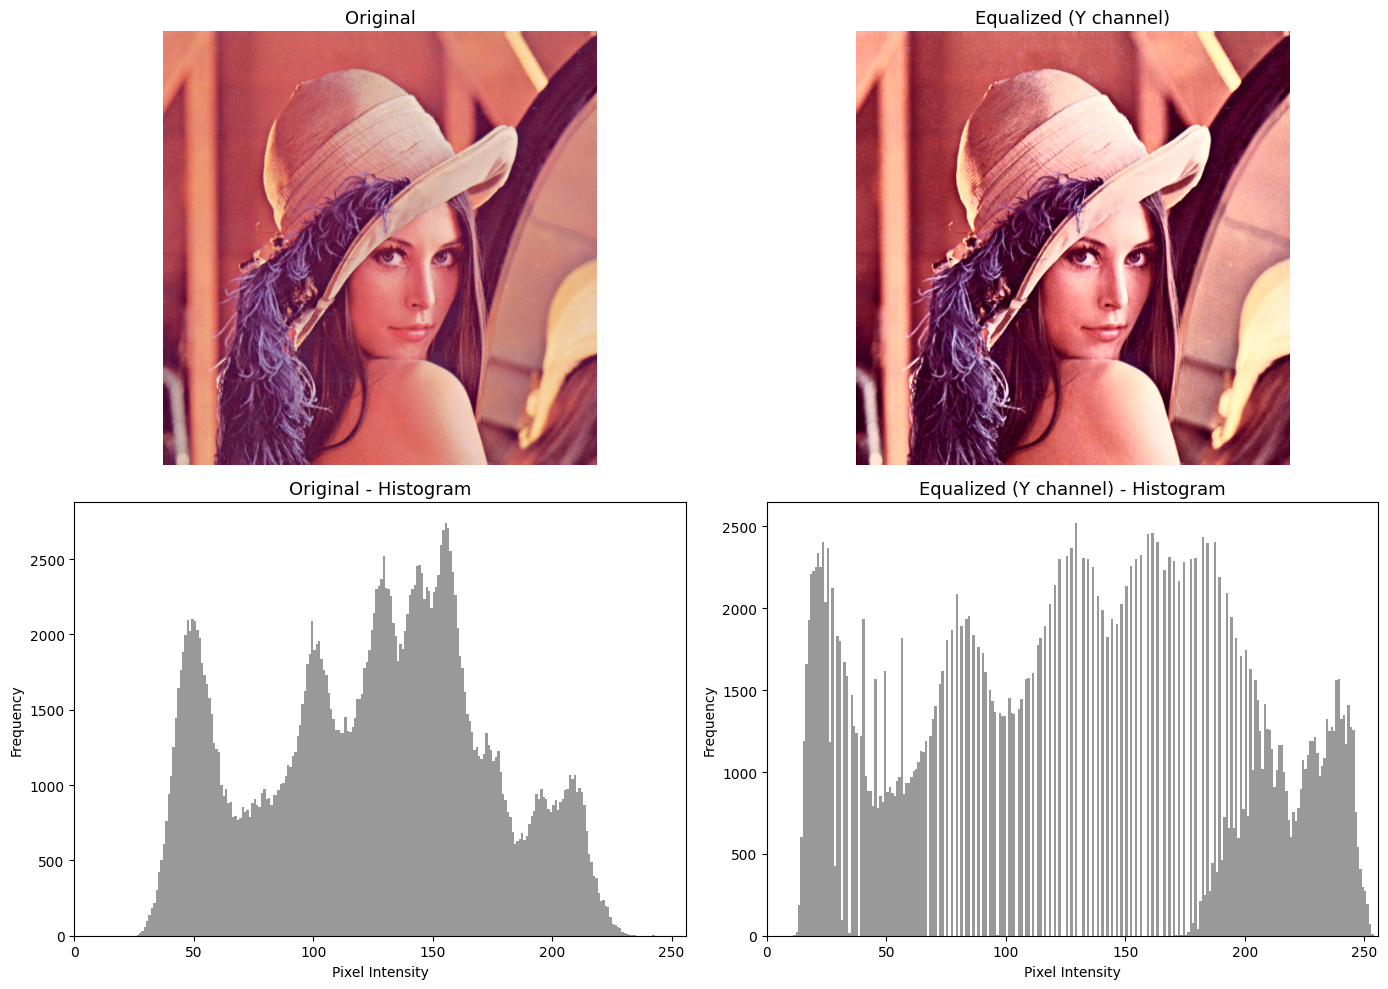

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 纯净读取同级目录下的 PNG 图片 (OpenCV 默认 BGR 顺序)
img_bgr = cv2.imread('ex_img/lena_color_512.png')

# 2. 将 BGR 转换为 RGB，以便后续用 matplotlib 正确渲染和计算
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. 切换到 YCrCb 颜色空间
img_ycrbc = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)

# 4. 仅对 Y (亮度) 通道进行直方图均衡化，保持 Cr, Cb 颜色通道不变
img_ycrbc[:, :, 0] = cv2.equalizeHist(img_ycrbc[:, :, 0])

# 5. 将均衡化后的 YCrCb 图像转换回 RGB 空间
img_eq = cv2.cvtColor(img_ycrbc, cv2.COLOR_YCrCb2RGB)

# 6. 创建 2x2 的画布进行原图与均衡化效果的横向对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

images = [img_rgb, img_eq]
titles = ["Original", "Equalized (Y channel)"]

for col in range(2):
    # 第一行：显示图像
    axes[0, col].imshow(images[col])
    axes[0, col].set_title(titles[col], fontsize=13)
    axes[0, col].axis('off')

    # 第二行：绘制对应的灰度直方图
    gray = cv2.cvtColor(images[col], cv2.COLOR_RGB2GRAY)
    axes[1, col].hist(gray.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.8)
    axes[1, col].set_title(f'{titles[col]} - Histogram', fontsize=13)
    axes[1, col].set_xlim([0, 256])
    axes[1, col].set_xlabel('Pixel Intensity')
    axes[1, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()